 # Groundwater Level Forecasting – 3-Layer LSTM (Full Notebook)

 This notebook performs:
 - Time selection
 - Feature engineering
 - Leak-free Train/Val/Test split
 - Scaling (train-only)
 - Sliding-window dataset creation
 - Grid Search for LSTM
 - Final retraining
 - Evaluation
 - Permutation Feature Importance
 - SHAP interpretability

## 0. Imports

In [44]:
%pip install tensorflow shap

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import shap

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.1)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("TensorFlow:", tf.__version__)

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
TensorFlow: 2.19.0


In [45]:
# ======================================================
# Experiment configuration
# ======================================================
SUBSET_NAME = "subset2"      # subset1 | subset2
ENGINEERED_MODE = "all"      # all | lag_only

AUTO_LOAD_MODEL = True
FORCE_RETRAIN = True

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. Load and Merge Data

In [46]:
# ======================================================
# Paths
# ======================================================
BASE_PATH = "."

path_level_rain_pressure = os.path.join(
    BASE_PATH, "data/nivel-pocos_chuva_pressao_tratados.csv"
)
path_wells_func = os.path.join(
    BASE_PATH, "data/funcionamento_pocos_30min.csv"
)
path_earth_tide = os.path.join(
    BASE_PATH, "data/earth_tide.csv"
)

# ======================================================
# Load data
# ======================================================
level_rain_pressure = pd.read_csv(path_level_rain_pressure)
wells_func = pd.read_csv(path_wells_func)
earth_tide = pd.read_csv(path_earth_tide)

# ======================================================
# Standardize datetime column
# ======================================================
if "datetime" in earth_tide.columns:
    earth_tide = earth_tide.rename(columns={"datetime": "date_time"})

for df_ in [level_rain_pressure, wells_func, earth_tide]:
    if "date_time" not in df_.columns:
        raise ValueError("Dataset missing 'date_time' column.")

# ======================================================
# Rename variables (standard naming)
# ======================================================
rename_map = {
    "pressao_mH2O_final": "baro_ig_mH2O",
    "gmu_level_mH2O_compensado": "gmu_gwl_mH2O",
    "chuva_mm_30min": "rain_mm_30min",
    "status_IMECC": "status_IME",
    "status_ZOOLOGIA": "status_IBZ",
}

level_rain_pressure = level_rain_pressure.rename(columns=rename_map)
wells_func = wells_func.rename(columns=rename_map)

# ======================================================
# Clean pumping status (binary)
# ======================================================
wells_func = wells_func.dropna()
pumping_cols = wells_func.columns.difference(["date_time"])
wells_func[pumping_cols] = wells_func[pumping_cols].astype(int)

# ======================================================
# Merge datasets
# ======================================================
data = (
    level_rain_pressure
    .merge(wells_func, on="date_time", how="outer")
    .merge(earth_tide, on="date_time", how="outer")
)

data["date_time"] = pd.to_datetime(data["date_time"])
data = data.sort_values("date_time").reset_index(drop=True)

print("Merged shape:", data.shape)

Merged shape: (70080, 8)


In [47]:
# ======================================================
# Statistical summary for groundwater level by subsets
# ======================================================

subsets = {
    "Subset 1": (
        "2022-05-11 15:30:00",
        "2022-07-11 11:00:00"
    ),
    "Subset 2": (
        "2024-12-08 23:00:00",
        "2025-08-14 16:00:00"
    )
}

results = []

for subset_name, (start_date, end_date) in subsets.items():

    subset = data[
        (data["date_time"] >= start_date) &
        (data["date_time"] <= end_date)
    ].copy()

    series = subset["gmu_gwl_mH2O"].dropna()

    if series.empty:
        print(f"{subset_name}: no valid data")
        continue

    stats_dict = {
        "subset": subset_name,
        "start": start_date,
        "end": end_date,
        "n": len(series),
        "mean": series.mean(),
        "median": series.median(),
        "std": series.std(),
        "min": series.min(),
        "25%": series.quantile(0.25),
        "50%": series.quantile(0.50),
        "75%": series.quantile(0.75),
        "max": series.max(),
        "range": series.max() - series.min(),
        "skewness": series.skew(),
        "kurtosis": series.kurt(),
    }

    results.append(stats_dict)

summary_subsets = pd.DataFrame(results)

display(summary_subsets)

summary_subsets.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "subset_statistics.csv"
    ),
    index=False
)

,subset,start,end,n,mean,median,std,min,25%,50%,75%,max,range,skewness,kurtosis
0,Subset 1,2022-05-11 15:30:00,2022-07-11 11:00:00,2920,21.597772,21.604792,0.281068,20.714187,21.420863,21.604792,21.815748,22.186641,1.472454,-0.494630,0.177381
1,Subset 2,2024-12-08 23:00:00,2025-08-14 16:00:00,11939,0.372593,-0.585697,2.779303,-3.499775,-2.169084,-0.585697,3.317544,4.810575,8.310350,0.342248,-1.536251


## 1.1 Filter Period

In [48]:
# ======================================================
# Filter analysis period
# ======================================================
SUBSET_PERIODS = {

    "subset1": (
        "2022-05-11 15:30:00",
        "2022-07-11 11:00:00"
    ),

    "subset2": (
        "2024-12-08 23:00:00",
        "2025-08-14 16:00:00"
    )
}

START_DATE, END_DATE = SUBSET_PERIODS[SUBSET_NAME]

data = data[
    (data["date_time"] >= START_DATE) &
    (data["date_time"] <= END_DATE)
].copy()

print(f"Using period {START_DATE} → {END_DATE}")
print("Shape after filtering:", data.shape)

# ======================================================
# Set time index
# ======================================================
df = data.set_index("date_time").copy()

Using period 2024-12-08 23:00:00 → 2025-08-14 16:00:00
Shape after filtering: (11939, 8)


## 2. Feature Engineering (NO dropna)

In [49]:
# ======================================================
# CONFIGURATION: engineered feature selection strategy
# ======================================================
# ======================================================
# Target
# ======================================================
target_col = "gmu_gwl_mH2O"

# ======================================================
# Feature engineering
# ======================================================

# -----------------------
# Autoregressive features
# -----------------------
df["gwl_lag_6h"] = df[target_col].shift(12)           # 6h = 12 × 30 min
df["gwl_diff_24h"] = df[target_col] - df[target_col].shift(48)  # 24h

# -----------------------
# Trend (low-pass filter)
# -----------------------
# 7 days = 7 × 24 × 2 = 336 steps
df["trend_component"] = (
    df[target_col]
    .rolling(window=336, center=False, min_periods=1)
    .mean()
)

# -----------------------
# Pumping aggregation
# -----------------------
pumping_cols = ["status_IME", "status_FEF", "status_IBZ"]
df["pumping_total"] = df[pumping_cols].sum(axis=1)

df["pumping_sum_7d"] = (
    df["pumping_total"]
    .rolling(window=336, min_periods=1)
    .sum()
)

# -----------------------
# Rainfall aggregation
# -----------------------
df["rain_sum_7d"] = (
    df["rain_mm_30min"]
    .rolling(window=336, min_periods=1)
    .sum()
)

# -----------------------
# Calendar feature
# -----------------------
df["weekday"] = (df.index.weekday < 5).astype(int)

# ======================================================
# Engineered feature selection (CONTROLLED)
# ======================================================

engineered_features_all = [
    "gwl_lag_6h",
    "gwl_diff_24h",
    "trend_component",
    "pumping_sum_7d",
    "rain_sum_7d",
    "weekday",
]

if ENGINEERED_MODE == "all":
    engineered_features = engineered_features_all

elif ENGINEERED_MODE == "lag_only":
    engineered_features = ["gwl_lag_6h"]

else:
    raise ValueError(
        "Invalid ENGINEERED_MODE. Use 'all' or 'lag_only'."
    )

# ======================================================
# Natural features (original variables only)
# ======================================================

excluded_cols = (
    [target_col] +
    engineered_features_all +   # remove ALL engineered cols from naturals
    ["pumping_total"]           # internal helper variable
)

natural_features = [
    col for col in df.columns
    if col not in excluded_cols
]

# ======================================================
# Final feature set (conditional)
# ======================================================

if ENGINEERED_MODE == "lag_only":
    candidate_features = ["gwl_lag_6h"]
else:
    candidate_features = natural_features + engineered_features

print("Engineered mode:", ENGINEERED_MODE)

print("\nFinal selected features:")
print(candidate_features)

# ======================================================
# Final modeling dataframe
# ======================================================
df_model = df[[target_col] + candidate_features].copy()

# ------------------------------------------------------
# Valid mask (ESSENTIAL)
# ------------------------------------------------------
valid_mask = df_model.notna().all(axis=1).values

print("Final modeling shape:", df_model[valid_mask].shape)


Engineered mode: all

Final selected features:
['baro_ig_mH2O', 'rain_mm_30min', 'status_IME', 'status_FEF', 'status_IBZ', 'earth_tide_nm/s2', 'gwl_lag_6h', 'gwl_diff_24h', 'trend_component', 'pumping_sum_7d', 'rain_sum_7d', 'weekday']
Final modeling shape: (11891, 13)


## 3. Train / Val / Test Split (Masked)

In [50]:
X_all = df_model[candidate_features].values
y_all = df_model[[target_col]].values

n = len(df_model)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

def masked_split(X, y, mask, a, b):
    return X[a:b], y[a:b], mask[a:b]

X_train_raw, y_train_raw, mask_train = masked_split(X_all, y_all, valid_mask, 0, train_end)
X_val_raw,   y_val_raw,   mask_val   = masked_split(X_all, y_all, valid_mask, train_end, val_end)
X_test_raw,  y_test_raw,  mask_test  = masked_split(X_all, y_all, valid_mask, val_end, n)

## 4. Scaling (fit only on valid TRAIN)

In [51]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaler_X.fit(X_train_raw[mask_train])
scaler_y.fit(y_train_raw[mask_train])

X_train_scaled = scaler_X.transform(X_train_raw)
X_val_scaled   = scaler_X.transform(X_val_raw)
X_test_scaled  = scaler_X.transform(X_test_raw)

y_train_scaled = scaler_y.transform(y_train_raw)
y_val_scaled   = scaler_y.transform(y_val_raw)
y_test_scaled  = scaler_y.transform(y_test_raw)

## 5. Sequence Creation (NO gaps)

In [52]:
def create_sequences_masked(X, y, mask, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        if not mask[i-window:i+1].all():
            continue
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

window_size = 240

X_train, y_train = create_sequences_masked(X_train_scaled, y_train_scaled, mask_train, window_size)
X_val,   y_val   = create_sequences_masked(X_val_scaled,   y_val_scaled,   mask_val,   window_size)
X_test,  y_test  = create_sequences_masked(X_test_scaled,  y_test_scaled,  mask_test,  window_size)

print("Final sequences:")
print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Final sequences:
Train: (8069, 240, 12)
Val:   (1551, 240, 12)
Test:  (1551, 240, 12)


 ## 6. 3-Layer LSTM Model + Grid Search

 ### 6. 3.1- Direct Train

In [53]:
import joblib

MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    f"{SUBSET_NAME}_{ENGINEERED_MODE}_lstm.keras"
)

MODEL_EXISTS = os.path.exists(MODEL_PATH)

print("Model exists:", MODEL_EXISTS)
print("Model path:", MODEL_PATH)

if AUTO_LOAD_MODEL and MODEL_EXISTS and not FORCE_RETRAIN:

    print(f"Loading existing model: {MODEL_PATH}")

    final_model = tf.keras.models.load_model(
        MODEL_PATH
    )

    scaler_X = joblib.load(
        os.path.join(
            OUTPUT_DIR,
            f"{SUBSET_NAME}_{ENGINEERED_MODE}_scaler_X.pkl"
        )
    )

    scaler_y = joblib.load(
        os.path.join(
            OUTPUT_DIR,
            f"{SUBSET_NAME}_{ENGINEERED_MODE}_scaler_y.pkl"
        )
    )

    candidate_features = joblib.load(
        os.path.join(
            OUTPUT_DIR,
            f"{SUBSET_NAME}_{ENGINEERED_MODE}_features.pkl"
        )
    )
    saved_features = candidate_features.copy()

    print("\nSaved features:")
    print(saved_features)

    if len(saved_features) != X_train.shape[2]:
        raise ValueError(
            "Feature count mismatch between model and notebook."
        )

    SKIP_TRAINING = True

else:

    print("Training new model...")

    SKIP_TRAINING = False

Model exists: True
Model path: outputs\subset2_all_lstm.keras
Training new model...


In [54]:
### TREINAR DIRETO

def build_lstm(input_shape,
               u1=64, u2=32, u3=16,
               dropout=0.1, lr=1e-3):
    
    model = Sequential([
        LSTM(u1, return_sequences=True, input_shape=input_shape),
        Dropout(dropout),
        LSTM(u2, return_sequences=True),
        Dropout(dropout),
        LSTM(u3, return_sequences=False),
        Dropout(dropout),
        Dense(1)
    ])
    
    model.compile(
        loss="mse",
        optimizer=Adam(lr),
        metrics=["mae"]
    )
    return model

# Fixed hyperparameters
params = {
    "u1": 128,
    "u2": 64,
    "u3": 32,
    "drop": 0.05,
    "lr": 5e-4,
    "batch": 32,
    "epochs": 50
}

if not SKIP_TRAINING:

    print("Training LSTM with fixed parameters:")
    print(params)

    input_shape = (
        X_train.shape[1],
        X_train.shape[2]
    )

    model = build_lstm(
        input_shape,
        u1=params["u1"],
        u2=params["u2"],
        u3=params["u3"],
        dropout=params["drop"],
        lr=params["lr"]
    )

    es = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=params["epochs"],
        batch_size=params["batch"],
        callbacks=[es],
        verbose=1
    )

    final_model = model

else:

    print("Using pretrained model.")

Training LSTM with fixed parameters:
{'u1': 128, 'u2': 64, 'u3': 32, 'drop': 0.05, 'lr': 0.0005, 'batch': 32, 'epochs': 50}


c:\Users\peliz\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 85s 313ms/step - loss: 0.0353 - mae: 0.1039 - val_loss: 3.6216e-04 - val_mae: 0.0148
Epoch 2/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 72s 285ms/step - loss: 0.0017 - mae: 0.0311 - val_loss: 8.0840e-04 - val_mae: 0.0248
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 68s 270ms/step - loss: 0.0015 - mae: 0.0287 - val_loss: 5.2498e-04 - val_mae: 0.0188
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 59s 235ms/step - loss: 0.0014 - mae: 0.0274 - val_loss: 1.8955e-04 - val_mae: 0.0106
Epoch 5/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 68s 268ms/step - loss: 0.0015 - mae: 0.0280 - val_loss: 5.3249e-04 - val_mae: 0.0199
Epoch 6/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 74s 294ms/step - loss: 0.0012 - mae: 0.0258 - val_loss: 8.8094e-04 - val_mae: 0.0261
Epoch 7/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 72s 286ms/step - loss: 0.0011 - mae: 0.0250 - val_loss: 5.8410e-04 - val_mae: 0.0205
Epoch 8/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 75s 297ms/step - loss: 0.0012 - mae: 0.0260 - val_loss: 0.0011 - val_mae: 0.0309
Epoc

In [55]:
import joblib

if not SKIP_TRAINING:
    final_model.save(
        os.path.join(
            OUTPUT_DIR,
            f"{SUBSET_NAME}_{ENGINEERED_MODE}_lstm.keras"
        )
    )

joblib.dump(
    scaler_X,
    os.path.join(
        OUTPUT_DIR,
        f"{SUBSET_NAME}_{ENGINEERED_MODE}_scaler_X.pkl"
    )
)

joblib.dump(
    scaler_y,
    os.path.join(
        OUTPUT_DIR,
        f"{SUBSET_NAME}_{ENGINEERED_MODE}_scaler_y.pkl"
    )
)

joblib.dump(
    candidate_features,
    os.path.join(
        OUTPUT_DIR,
        f"{SUBSET_NAME}_{ENGINEERED_MODE}_features.pkl"
    )
)

print("Model and scalers saved.")

Model and scalers saved.


### Gráfico de training loss e validation loss

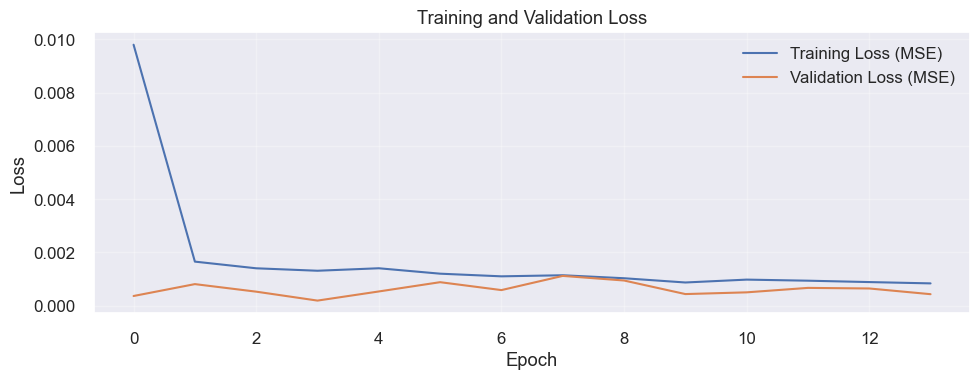

In [56]:
import matplotlib.pyplot as plt

if not SKIP_TRAINING:

    plt.figure(figsize=(10, 4))

    plt.plot(
        history.history["loss"],
        label="Training Loss (MSE)"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss (MSE)"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

 ## 8. Evaluation on Test Set

49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step
R²  = 0.8288555319320959
MAE = 0.22528443350408062
RMSE= 0.23977511258884354
NSE = 0.8288555319320959


,R2,MAE,RMSE,NSE
0,0.828856,0.225284,0.239775,0.828856


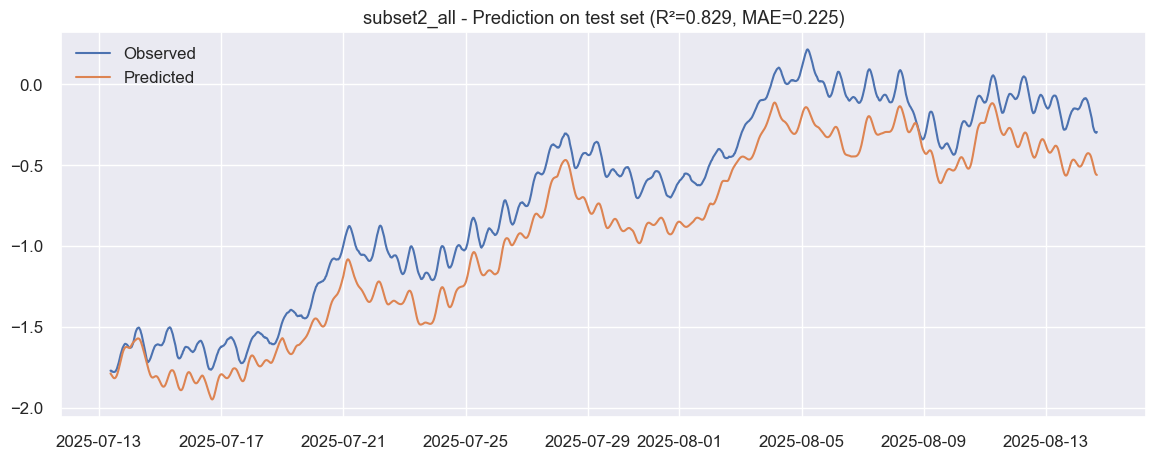

In [57]:
y_pred_scaled = final_model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

r2   = r2_score(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
nse  = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)

print("R²  =", r2)
print("MAE =", mae)
print("RMSE=", rmse)
print("NSE =", nse)

metrics_df = pd.DataFrame([{
    "R2": r2,
    "MAE": mae,
    "RMSE": rmse,
    "NSE": nse
}])

metrics_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"{SUBSET_NAME}_{ENGINEERED_MODE}_metrics.csv"
    ),
    index=False
)

display(metrics_df)

article_metrics = {
    "subset": SUBSET_NAME,
    "mode": ENGINEERED_MODE,
    "R2": r2,
    "NSE": nse,
    "MAE": mae,
    "RMSE": rmse
}

pd.DataFrame([article_metrics]).to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"{SUBSET_NAME}_{ENGINEERED_MODE}_ARTICLE_METRICS.csv"
    ),
    index=False
)

timestamps = df_model.index[
    window_size + val_end :
    window_size + val_end + len(y_test)
]

plt.figure(figsize=(14,5))
plt.plot(timestamps, y_true, label="Observed")
plt.plot(timestamps, y_pred, label="Predicted")
plt.title(f"{SUBSET_NAME}_{ENGINEERED_MODE} - Prediction on test set (R²={r2:.3f}, MAE={mae:.3f})")
plt.legend()
plt.grid(True)
plt.show()

# subset1_lagonly_LSTM_predXreal_graph


### Residual Time Series (Test − Prediction)

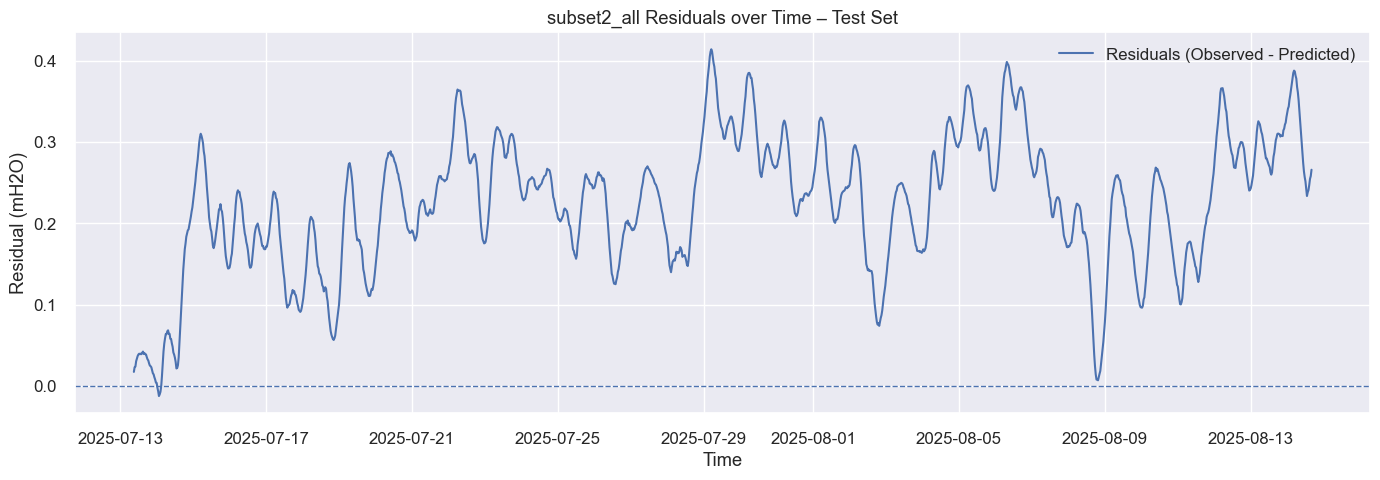

In [58]:
# ==========================================================
# Residual analysis
# ==========================================================

# Compute residuals
residuals = y_true.flatten() - y_pred.flatten()

predictions_df = pd.DataFrame({
    "timestamp": timestamps,
    "observed": y_true.flatten(),
    "predicted": y_pred.flatten(),
    "residual": residuals
})

predictions_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"{SUBSET_NAME}_{ENGINEERED_MODE}_predictions.csv"
    ),
    index=False
)

residual_summary = {
    "mean_residual": residuals.mean(),
    "median_residual": np.median(residuals),
    "std_residual": residuals.std()
}

pd.DataFrame([residual_summary]).to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"{SUBSET_NAME}_{ENGINEERED_MODE}_RESIDUAL_SUMMARY.csv"
    ),
    index=False
)

# ----------------------------------------------------------
# Plot residuals over time
# ----------------------------------------------------------
plt.figure(figsize=(14, 5))

plt.plot(
    timestamps,
    residuals,
    label="Residuals (Observed - Predicted)"
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Time")
plt.ylabel("Residual (mH2O)")
plt.title(f"{SUBSET_NAME}_{ENGINEERED_MODE} Residuals over Time – Test Set")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# {SUBSET_NAME}_{ENGINEERED_MODE}_residuals



### Residual Distribution

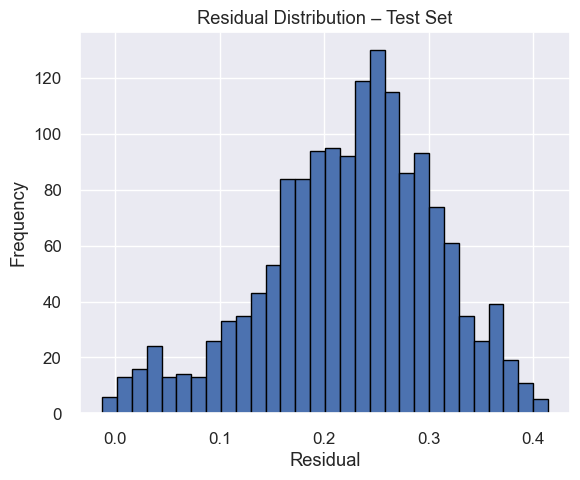

In [59]:
# ----------------------------------------------------------
# Residual distribution
# ----------------------------------------------------------
plt.figure(figsize=(6, 5))

plt.hist(residuals, bins=30, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution – Test Set")
plt.grid(True)
plt.tight_layout()
plt.show()

### Residuals vs Physical and Operational Features
 Align residuals with original dataset

In [60]:
# Create DataFrame with residuals indexed by time
df_residuals = pd.DataFrame(
    {
        "residual": residuals.flatten()
    },
    index=timestamps
)

# Select features from original dataset
features_to_analyze = [
    "baro_ig_mH2O",
    "rain_mm_30min",
    "status_IME",
    "status_FEF",
    "status_IBZ",
    "earth_tide_nm/s2"
]

df_features = df.loc[df_residuals.index, features_to_analyze]

# Merge
df_res = pd.concat([df_residuals, df_features], axis=1).dropna()

print("Residual-feature dataset shape:", df_res.shape)
df_res.head()

Residual-feature dataset shape: (1551, 7)


,residual,baro_ig_mH2O,rain_mm_30min,status_IME,status_FEF,status_IBZ,earth_tide_nm/s2
date_time,,,,,,,
2025-07-13 09:00:00,0.017316,9.738574,0.0,0.0,1.0,0.0,175.611
2025-07-13 09:30:00,0.023127,9.740894,0.0,0.0,1.0,0.0,418.451
2025-07-13 10:00:00,0.023708,9.742582,0.0,0.0,1.0,0.0,614.070
2025-07-13 10:30:00,0.030450,9.742089,0.0,0.0,1.0,0.0,753.335
2025-07-13 11:00:00,0.033570,9.740894,0.0,0.0,1.0,0.0,830.956


### Residual vs Feature Plots

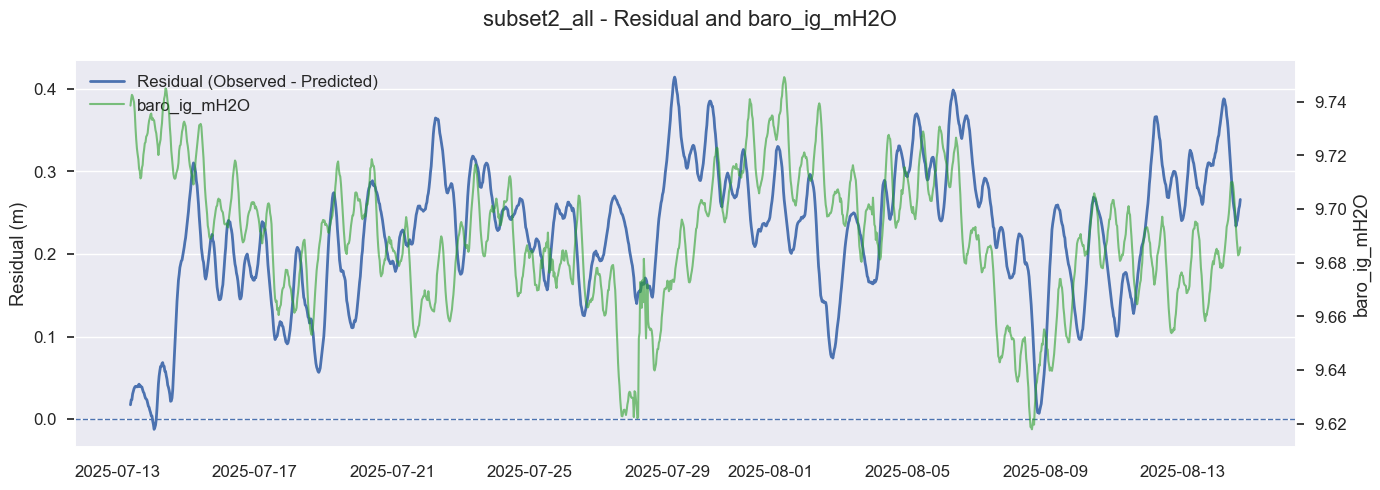

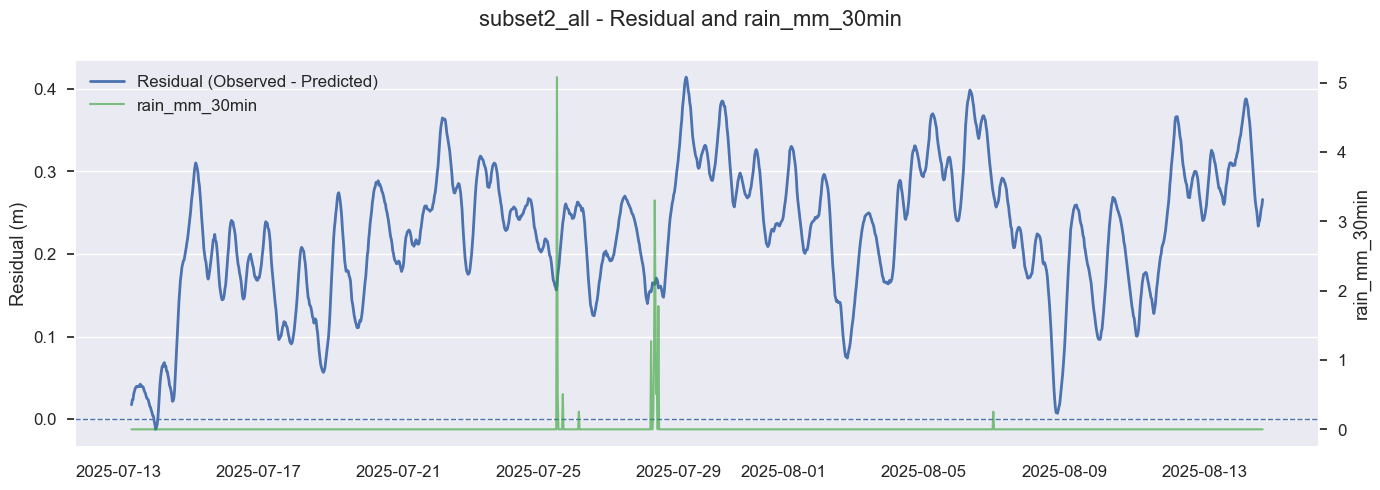

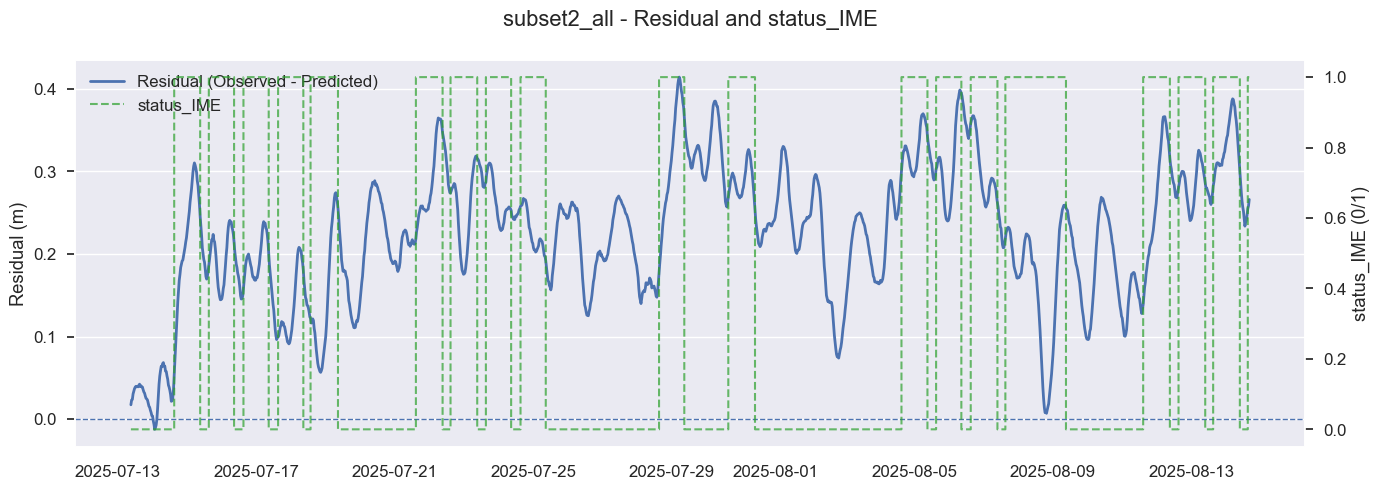

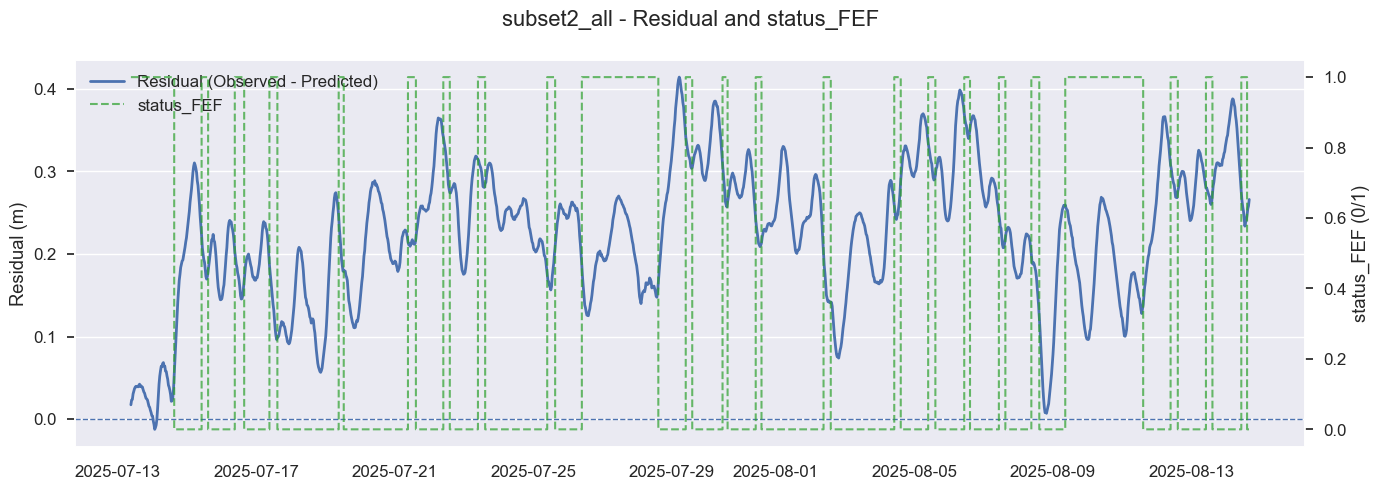

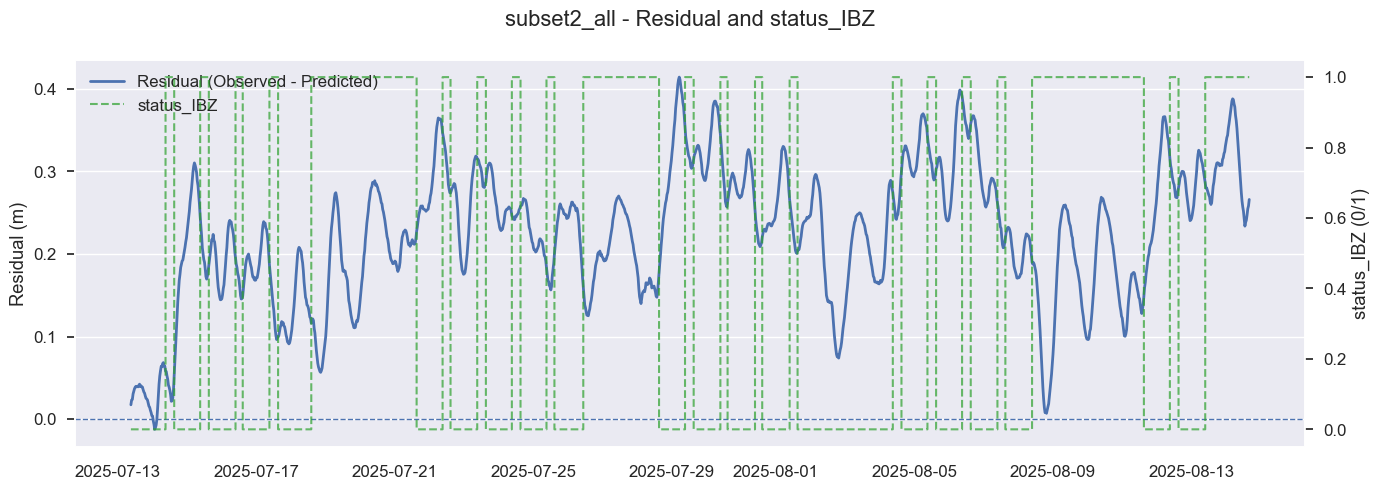

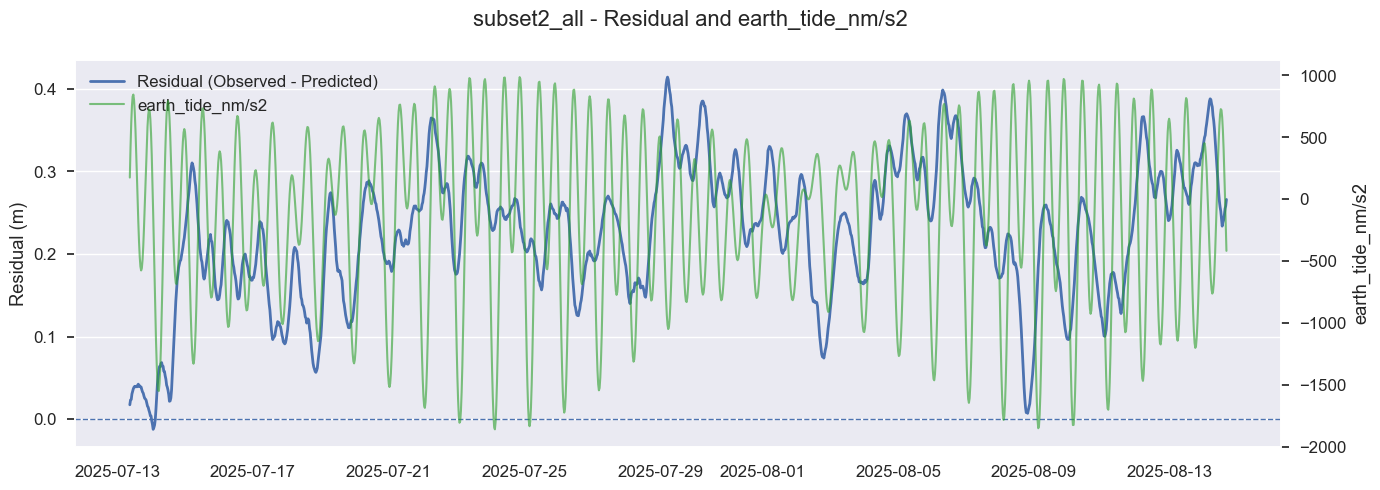

In [61]:
# ----------------------------------------------------------
# Analysis over the FULL test period
# ----------------------------------------------------------

rename_map = {
    "pressao_mH2O_final": "baro_ig_mH2O",
    "chuva_mm_30min": "rain_mm_30min"
}

FEATURE_COLOR = "tab:green"   # <<< verde claro padrão do matplotlib

for feat in features_to_analyze:
    
    feat_label = rename_map.get(feat, feat)

    fig, ax1 = plt.subplots(figsize=(14, 5))
    
    # Plot residuals
    ax1.plot(
        df_res.index,
        df_res["residual"],
        label="Residual (Observed - Predicted)",
        linewidth=2
    )
    ax1.set_ylabel("Residual (m)")
    ax1.axhline(0, linestyle="--", linewidth=1)
    
    # Second axis for feature
    ax2 = ax1.twinx()
    
    if df_res[feat].nunique() <= 2:
        ax2.step(
            df_res.index,
            df_res[feat],
            where="post",
            linestyle="--",
            alpha=0.7,
            color=FEATURE_COLOR,     # <<< AQUI
            label=feat_label
        )
        ax2.set_ylabel(f"{feat_label} (0/1)")
    else:
        ax2.plot(
            df_res.index,
            df_res[feat],
            alpha=0.6,
            color=FEATURE_COLOR,     # <<< AQUI
            label=feat_label
        )
        ax2.set_ylabel(feat_label)
    
    # Title and legend
    fig.suptitle(f"{SUBSET_NAME}_{ENGINEERED_MODE} - Residual and {feat_label}")
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    
    # Grid configuration
    ax1.grid(axis="x")
    ax2.grid(False)
    
    fig.tight_layout()
    plt.show()


### Pearson Correlation between Residuals and Features

In [62]:
pearson_results = []

for feat in features_to_analyze:
    corr = df_res["residual"].corr(df_res[feat], method="pearson")
    pearson_results.append((feat, corr))

pearson_df = pd.DataFrame(
    pearson_results,
    columns=["Feature", "Pearson_r"]
).sort_values("Pearson_r", key=np.abs, ascending=False)

pearson_df

,Feature,Pearson_r
3,status_FEF,-0.309924
2,status_IME,0.214022
4,status_IBZ,-0.159958
1,rain_mm_30min,-0.044780
0,baro_ig_mH2O,0.042778
5,earth_tide_nm/s2,0.022885


### Cross-Correlation Analysis (Residual × Feature)

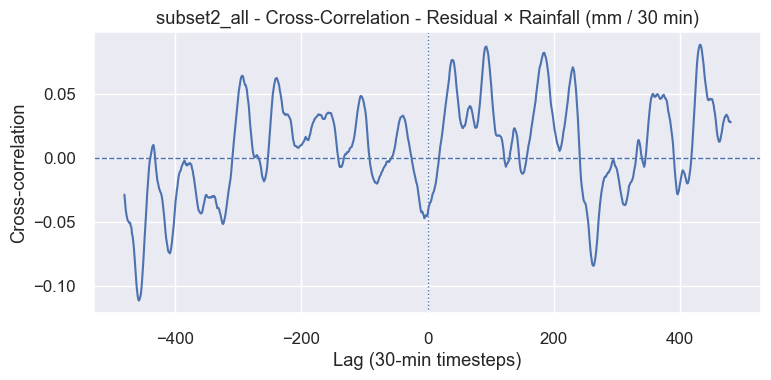

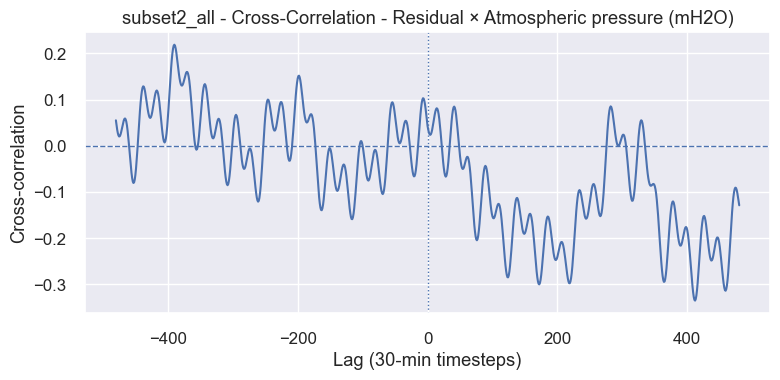

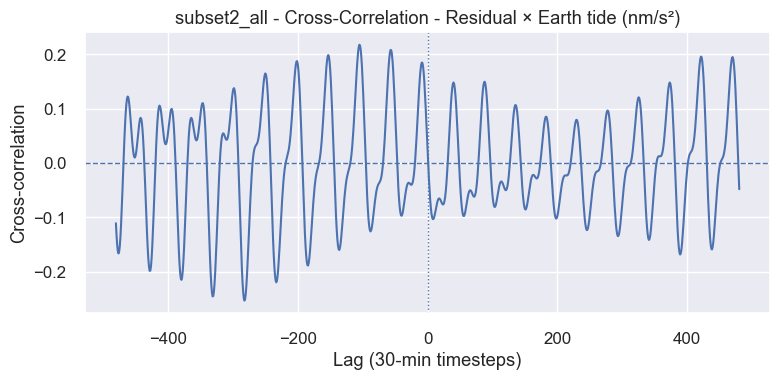

In [63]:
def cross_correlation(x, y, max_lag):
    lags = np.arange(-max_lag, max_lag + 1)
    ccs = []

    for lag in lags:
        if lag < 0:
            ccs.append(np.corrcoef(x[:lag], y[-lag:])[0, 1])
        elif lag > 0:
            ccs.append(np.corrcoef(x[lag:], y[:-lag])[0, 1])
        else:
            ccs.append(np.corrcoef(x, y)[0, 1])

    return lags, np.array(ccs)

# Only continuous features
continuous_features = {
    "rain_mm_30min": "Rainfall (mm / 30 min)",
    "baro_ig_mH2O": "Atmospheric pressure (mH2O)",
    "earth_tide_nm/s2": "Earth tide (nm/s²)"
}

max_lag = 480  # ±10 days for 30-min data

x = df_res["residual"].values

for feat, label in continuous_features.items():

    y = df_res[feat].values

    mask = ~np.isnan(x) & ~np.isnan(y)
    x_f = x[mask]
    y_f = y[mask]

    lags, ccs = cross_correlation(x_f, y_f, max_lag)

    plt.figure(figsize=(8, 4))
    plt.plot(lags, ccs)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle=":", linewidth=1)
    plt.xlabel("Lag (30-min timesteps)")
    plt.ylabel("Cross-correlation")
    plt.title(f"{SUBSET_NAME}_{ENGINEERED_MODE} - Cross-Correlation - Residual × {label}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # {SUBSET_NAME}_{ENGINEERED_MODE}_CrossCor_residual_

### Before–After Analysis for Binary Operational Variables

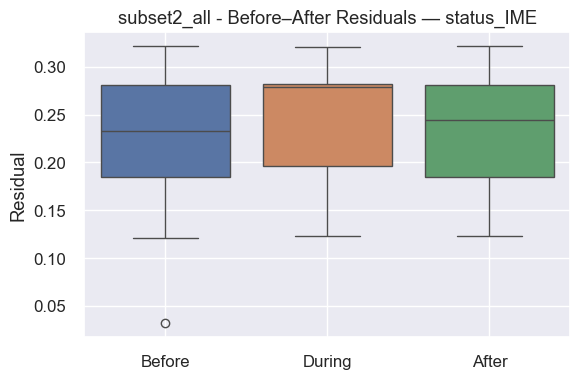


status_IME — Mean residuals:
Before    0.232792
During    0.279022
After     0.244283
dtype: float64

ARTICLE_BDA_RESULTS:
{'before': 0.23279204235245554, 'during': 0.27902156838603254, 'after': 0.2442825207229121, 'max_difference': 0.046229526033576995}


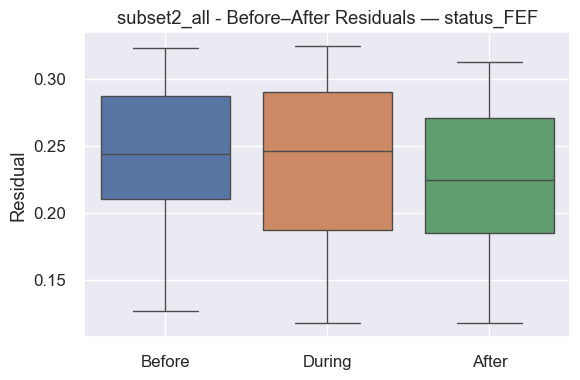


status_FEF — Mean residuals:
Before    0.243736
During    0.245906
After     0.224313
dtype: float64

ARTICLE_BDA_RESULTS:
{'before': 0.24373613427319724, 'during': 0.2459063523335745, 'after': 0.22431304930313678, 'max_difference': 0.021593303030437716}


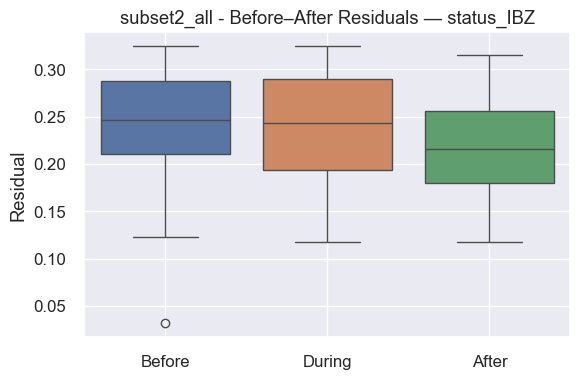


status_IBZ — Mean residuals:
Before    0.245906
During    0.243369
After     0.216033
dtype: float64

ARTICLE_BDA_RESULTS:
{'before': 0.2459063523335745, 'during': 0.24336920450627392, 'after': 0.2160330052475914, 'max_difference': 0.029873347085983104}


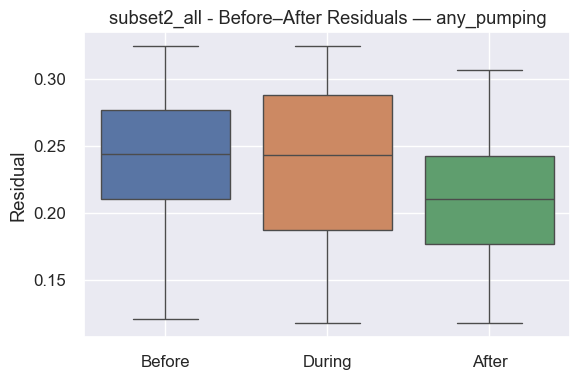


any_pumping — Mean residuals:
Before    0.243736
During    0.243369
After     0.210638
dtype: float64

ARTICLE_BDA_RESULTS:
{'before': 0.24373613427319724, 'during': 0.24336920450627392, 'after': 0.21063819572260378, 'max_difference': 0.03309793855059345}


In [64]:
def before_after_analysis(
    df,
    status_col,
    residual_col="residual",
    pre_steps=48,
    post_steps=48
):
    """
    Computes mean residual before, during, and after operational events.
    """
    
    events = df.index[df[status_col].diff() == 1]  # OFF → ON
    
    records = []

    for t0 in events:
        idx = df.index.get_loc(t0)

        if idx - pre_steps < 0 or idx + post_steps >= len(df):
            continue

        before = df.iloc[idx - pre_steps:idx][residual_col].median()
        during = df.iloc[idx:idx + pre_steps][residual_col].median()
        after  = df.iloc[idx + pre_steps:idx + pre_steps + post_steps][residual_col].median()

        records.append([before, during, after])

    return pd.DataFrame(
        records,
        columns=["Before", "During", "After"]
    )

df_res["any_pumping"] = (
    (
        df_res["status_IME"]
        +
        df_res["status_FEF"]
        +
        df_res["status_IBZ"]
    ) > 0
).astype(int)

status_vars = [
    "status_IME",
    "status_FEF",
    "status_IBZ",
    "any_pumping"
]

global_bda_results = []

for status in status_vars:
    
    ba = before_after_analysis(
        df_res,
        status_col=status,
        pre_steps=48,   # 24h
        post_steps=48
    )
    
    if ba.empty:
        print(f"No valid events for {status}")
        continue

    plt.figure(figsize=(6, 4))
    sns.boxplot(data=ba)
    plt.title(f"{SUBSET_NAME}_{ENGINEERED_MODE} - Before–After Residuals — {status}")
    plt.ylabel("Residual")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\n{status} — Mean residuals:")
    print(ba.median())

    bda_stats = {
        "before": ba["Before"].median(),
        "during": ba["During"].median(),
        "after": ba["After"].median()
    }

    bda_stats["max_difference"] = (
        max(bda_stats.values())
        -
        min(bda_stats.values())
    )

    global_bda_results.append(
        {
            "status": status,
            "before": bda_stats["before"],
            "during": bda_stats["during"],
            "after": bda_stats["after"],
            "max_difference": bda_stats["max_difference"]
        }
    )

    print(
        "\nARTICLE_BDA_RESULTS:"
    )

    print(bda_stats)

    ba.to_csv(
        os.path.join(
            OUTPUT_DIR,
            f"{SUBSET_NAME}_{status}_BDA.csv"
        ),
        index=False
    )

In [65]:
bda_article_df = pd.DataFrame(
    global_bda_results
)

display(bda_article_df)

bda_article_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"{SUBSET_NAME}_BDA_article_values.csv"
    ),
    index=False
)

print(
    "\nARTICLE_BDA_MAX_DIFFERENCE =",
    bda_article_df["max_difference"].max()
)

,status,before,during,after,max_difference
0,status_IME,0.232792,0.279022,0.244283,0.046230
1,status_FEF,0.243736,0.245906,0.224313,0.021593
2,status_IBZ,0.245906,0.243369,0.216033,0.029873
3,any_pumping,0.243736,0.243369,0.210638,0.033098



ARTICLE_BDA_MAX_DIFFERENCE = 0.046229526033576995


### Superposed Epoch Analysis (SEA)

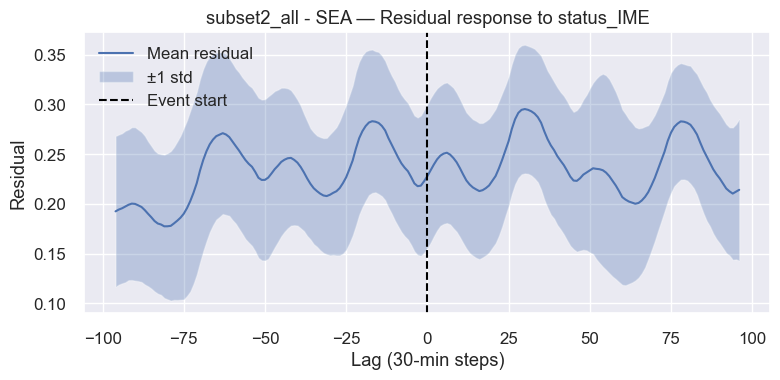

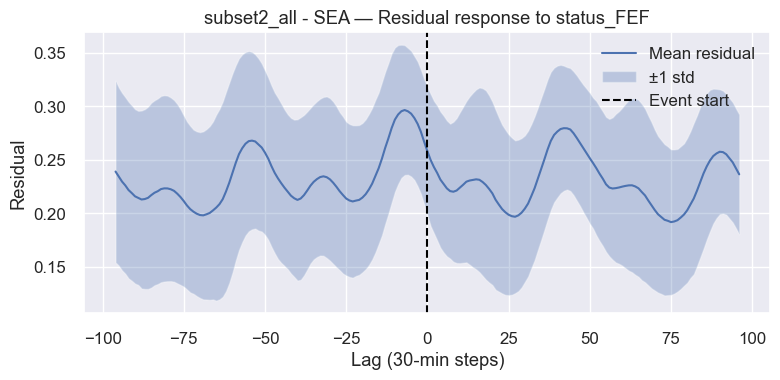

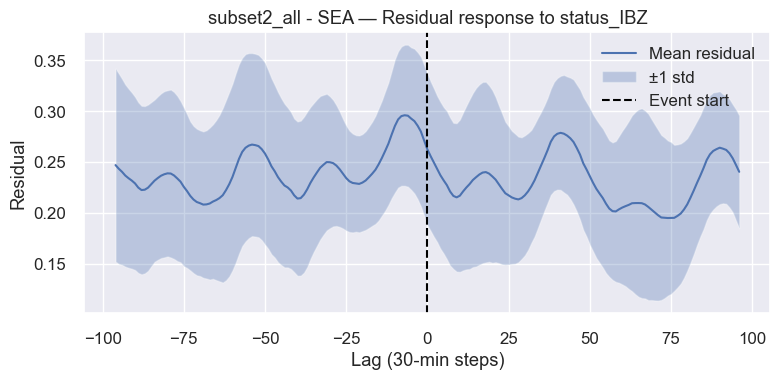

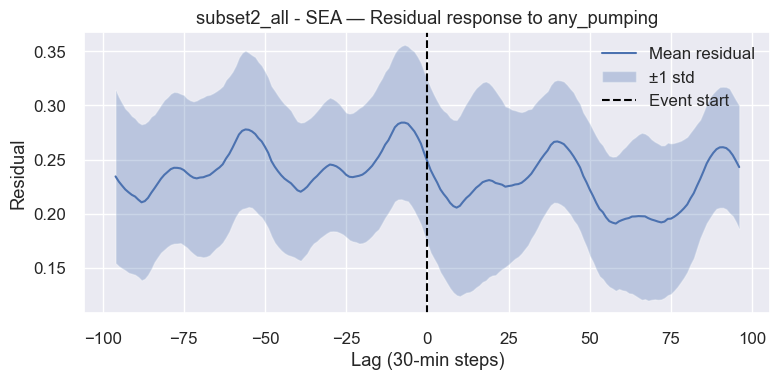

In [66]:
def superposed_epoch_analysis(
    df,
    status_col,
    residual_col="residual",
    window=96
):
    """
    Computes SEA around ON events.
    """
    
    events = df.index[df[status_col].diff() == 1]
    epochs = []

    for t0 in events:
        idx = df.index.get_loc(t0)

        if idx - window < 0 or idx + window >= len(df):
            continue

        epoch = df.iloc[idx - window:idx + window + 1][residual_col].values
        epochs.append(epoch)

    return np.array(epochs)

for status in status_vars:
    
    epochs = superposed_epoch_analysis(
        df_res,
        status_col=status,
        window=96  # ±48h
    )

    if len(epochs) == 0:
        print(f"No valid epochs for {status}")
        continue

    mean_epoch = np.mean(epochs, axis=0)
    std_epoch  = np.std(epochs, axis=0)

    sea_df = pd.DataFrame({
        "lag": np.arange(-96,97),
        "mean": mean_epoch,
        "std": std_epoch
    })

    sea_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            f"{SUBSET_NAME}_{status}_SEA.csv"
        ),
        index=False
    )

    lags = np.arange(-96, 97)

    plt.figure(figsize=(8, 4))
    plt.plot(lags, mean_epoch, label="Mean residual")
    plt.fill_between(
        lags,
        mean_epoch - std_epoch,
        mean_epoch + std_epoch,
        alpha=0.3,
        label="±1 std"
    )
    plt.axvline(0, linestyle="--", color="black", label="Event start")
    plt.xlabel("Lag (30-min steps)")
    plt.ylabel("Residual")
    plt.title(f"{SUBSET_NAME}_{ENGINEERED_MODE} - SEA — Residual response to {status}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # S1_LSTM_LAG_SEA_residual_

 ## 9. Permutation Feature Importance

49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step


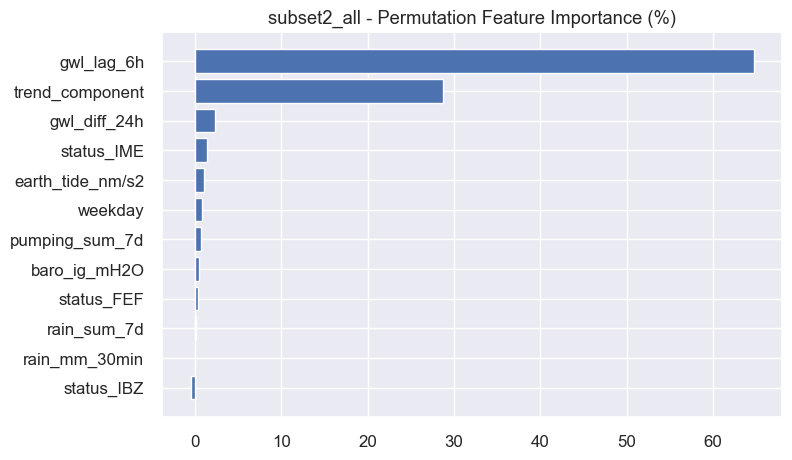

gwl_lag_6h: 64.79%
trend_component: 28.77%
gwl_diff_24h: 2.27%
status_IME: 1.34%
earth_tide_nm/s2: 0.99%
weekday: 0.80%
pumping_sum_7d: 0.74%
baro_ig_mH2O: 0.42%
status_FEF: 0.31%
rain_sum_7d: 0.07%
rain_mm_30min: -0.00%
status_IBZ: -0.51%


,feature,pfi_pct
6,gwl_lag_6h,64.790558
8,trend_component,28.774353
7,gwl_diff_24h,2.270565
2,status_IME,1.341476
5,earth_tide_nm/s2,0.988955
11,weekday,0.803009
9,pumping_sum_7d,0.740023
0,baro_ig_mH2O,0.424950
3,status_FEF,0.312372
10,rain_sum_7d,0.068546


PFI sum: 100.0


In [67]:
base_mse = mean_squared_error(y_test, y_pred_scaled)

feature_names = candidate_features
n_feat = len(feature_names)
importances = []

for j in range(n_feat):
    Xp = X_test.copy()
    perm = np.random.permutation(len(Xp))
    Xp[:, :, j] = Xp[perm, :, j]
    
    y_pp = final_model.predict(Xp)
    mse_p = mean_squared_error(y_test, y_pp)
    
    importances.append(mse_p - base_mse)

importances = np.array(importances)
importances_pct = importances / importances.sum() * 100
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.barh(
    [feature_names[i] for i in sorted_idx][::-1],
    importances_pct[sorted_idx][::-1]
)
plt.title(f"{SUBSET_NAME}_{ENGINEERED_MODE} - Permutation Feature Importance (%)")
plt.show()

for i in sorted_idx:
    print(f"{feature_names[i]}: {importances_pct[i]:.2f}%")

pfi_df = pd.DataFrame({
    "feature": feature_names,
    "pfi_pct": importances_pct
})

pfi_df = pfi_df.sort_values(
    "pfi_pct",
    ascending=False
)

pfi_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"{SUBSET_NAME}_{ENGINEERED_MODE}_PFI.csv"
    ),
    index=False
)

display(pfi_df)
print(
    "PFI sum:",
    round(
        pfi_df["pfi_pct"].sum(),
        2
    )
)

Calcular PFI necessário para o artigo

In [68]:
# ======================================================
# ARTICLE - PFI values
# ======================================================

pfi_lookup = pfi_df.set_index("feature")

selected_features = [
    f for f in [
        "gwl_lag_6h",
        "gwl_diff_24h"
    ]
    if f in pfi_lookup.index
]

if len(selected_features) > 0:

    pfi_cumulative = (
        pfi_lookup.loc[
            selected_features,
            "pfi_pct"
        ].sum()
    )

    print(
        "\nARTICLE_PFI_LAG_PLUS_DIFF =",
        round(pfi_cumulative, 2)
    )

else:

    pfi_cumulative = np.nan

    print(
        "\nARTICLE_PFI_LAG_PLUS_DIFF = Not available"
    )

# Store for article summary
article_pfi_results = {
    "lag_diff_pfi_pct": pfi_cumulative
}

article_pfi_df = pd.DataFrame(
    [article_pfi_results]
)

article_pfi_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"{SUBSET_NAME}_{ENGINEERED_MODE}_PFI_article_values.csv"
    ),
    index=False
)

display(article_pfi_df)


ARTICLE_PFI_LAG_PLUS_DIFF = 67.06


,lag_diff_pfi_pct
0,67.061123


 ## 10. SHAP Values (Kernel SHAP for LSTM)

  0%|          | 0/40 [00:00<?, ?it/s]

c:\Users\peliz\anaconda3\Lib\site-packages\sklearn\linear_model\_least_angle.py:639: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=4.972e-04, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(


,feature,shap_pct
5,earth_tide_nm/s2,19.223195
6,gwl_lag_6h,12.728424
7,gwl_diff_24h,10.561388
8,trend_component,10.273326
0,baro_ig_mH2O,9.947251
3,status_FEF,8.205688
9,pumping_sum_7d,7.538146
4,status_IBZ,7.100551
2,status_IME,5.528044
10,rain_sum_7d,3.403226



=== SHAP Global Feature Importance ===
earth_tide_nm/s2: 0.000006
gwl_lag_6h: 0.000004
gwl_diff_24h: 0.000003
trend_component: 0.000003
baro_ig_mH2O: 0.000003
status_FEF: 0.000003
pumping_sum_7d: 0.000002
status_IBZ: 0.000002
status_IME: 0.000002
rain_sum_7d: 0.000001
rain_mm_30min: 0.000001
weekday: 0.000001


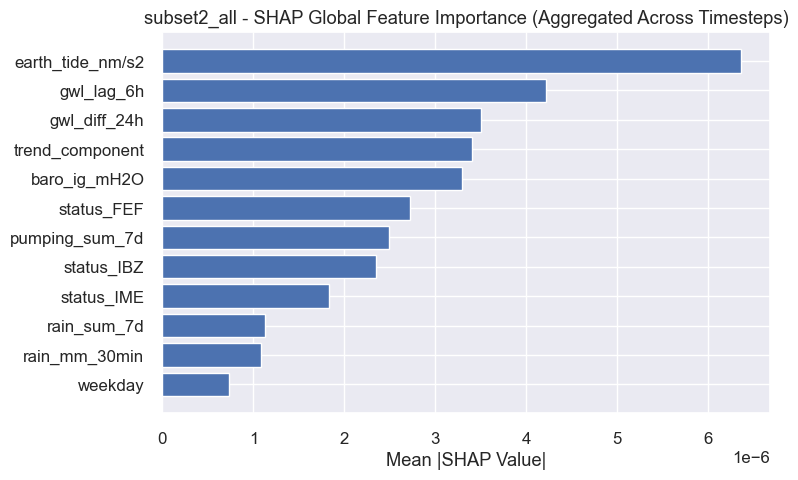

In [69]:
n_samples, time_steps, n_features = X_train.shape

X_train_flat = X_train.reshape((n_samples, time_steps * n_features))
X_background = X_train_flat[:50]

def model_wrapper(x_flat):
    x = x_flat.reshape((x_flat.shape[0], time_steps, n_features))
    return final_model.predict(x, verbose=0)

explainer = shap.KernelExplainer(
    model=model_wrapper,
    data=X_background
)

X_sample = X_train_flat[:40]
shap_values = explainer.shap_values(X_sample, nsamples=200)

shap_values = np.array(shap_values).reshape(
    len(X_sample),
    time_steps,
    n_features
)

mean_abs_shap = np.mean(np.abs(shap_values), axis=(0, 1))
sorted_idx = np.argsort(mean_abs_shap)[::-1]

shap_pct = (
    mean_abs_shap /
    mean_abs_shap.sum()
) * 100

shap_df = pd.DataFrame({
    "feature": feature_names,
    "shap_pct": shap_pct
})

shap_df = shap_df.sort_values(
    "shap_pct",
    ascending=False
)

shap_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"{SUBSET_NAME}_{ENGINEERED_MODE}_SHAP.csv"
    ),
    index=False
)

display(shap_df)
shap_df["shap_pct"].sum()

print("\n=== SHAP Global Feature Importance ===")
for i in sorted_idx:
    print(f"{feature_names[i]}: {mean_abs_shap[i]:.6f}")

plt.figure(figsize=(8,5))
plt.barh(
    [feature_names[i] for i in sorted_idx][::-1],
    mean_abs_shap[sorted_idx][::-1]
)
plt.title(f"{SUBSET_NAME}_{ENGINEERED_MODE} - SHAP Global Feature Importance (Aggregated Across Timesteps)")
plt.xlabel("Mean |SHAP Value|")
plt.tight_layout()
plt.show()

In [70]:
shap_lookup = shap_df.set_index("feature")

results_article = {}

# --------------------------------------------------
# Earth tide
# --------------------------------------------------

if "earth_tide_nm/s2" in shap_lookup.index:
    results_article["earth_tide_pct"] = (
        shap_lookup.loc[
            "earth_tide_nm/s2",
            "shap_pct"
        ]
    )

# --------------------------------------------------
# Atmospheric pressure
# --------------------------------------------------

if "baro_ig_mH2O" in shap_lookup.index:
    results_article["barometric_pct"] = (
        shap_lookup.loc[
            "baro_ig_mH2O",
            "shap_pct"
        ]
    )

# --------------------------------------------------
# Rain variables
# --------------------------------------------------

rain_features = [
    c for c in shap_lookup.index
    if "rain" in c.lower()
]

if len(rain_features) > 0:
    results_article["precipitation_pct"] = (
        shap_lookup.loc[
            rain_features,
            "shap_pct"
        ].sum()
    )

# --------------------------------------------------
# Trend
# --------------------------------------------------

if "trend_component" in shap_lookup.index:
    results_article["trend_pct"] = (
        shap_lookup.loc[
            "trend_component",
            "shap_pct"
        ]
    )

# --------------------------------------------------
# Pumping
# --------------------------------------------------

pump_features = [
    c for c in shap_lookup.index
    if (
        "status" in c.lower()
        or
        "pumping" in c.lower()
    )
]

if len(pump_features) > 0:
    results_article["pumping_pct"] = (
        shap_lookup.loc[
            pump_features,
            "shap_pct"
        ].sum()
    )

# --------------------------------------------------
# Lag + Diff
# --------------------------------------------------

lag_diff_features = [
    f for f in [
        "gwl_lag_6h",
        "gwl_diff_24h"
    ]
    if f in shap_lookup.index
]

if len(lag_diff_features) > 0:
    results_article["lag_diff_pct"] = (
        shap_lookup.loc[
            lag_diff_features,
            "shap_pct"
        ].sum()
    )

# --------------------------------------------------
# Lag + Diff + Earth Tide
# --------------------------------------------------

group_features = [
    f for f in [
        "gwl_lag_6h",
        "gwl_diff_24h",
        "earth_tide_nm/s2"
    ]
    if f in shap_lookup.index
]

if len(group_features) > 0:
    results_article["lag_diff_tide_pct"] = (
        shap_lookup.loc[
            group_features,
            "shap_pct"
        ].sum()
    )

print("\nARTICLE SHAP VALUES")
print(results_article)


ARTICLE SHAP VALUES
{'earth_tide_pct': 19.22319452660488, 'barometric_pct': 9.947251028748704, 'precipitation_pct': 6.683787895959375, 'trend_pct': 10.273326485727239, 'pumping_pct': 28.37242814571394, 'lag_diff_pct': 23.28981140462728, 'lag_diff_tide_pct': 42.51300593123216}


In [71]:
# ======================================================
# FINAL ARTICLE RESULTS
# ======================================================

article_results = {}

article_results.update(article_metrics)

if "article_pfi_results" in globals():
    article_results.update(article_pfi_results)

if "results_article" in globals():
    article_results.update(results_article)

if (
    "bda_article_df" in globals()
    and
    not bda_article_df.empty
):
    article_results["bda_max_difference"] = (
        bda_article_df["max_difference"].max()
    )

article_results_df = pd.DataFrame(
    [article_results]
)

display(article_results_df)

article_results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"{SUBSET_NAME}_{ENGINEERED_MODE}_ARTICLE_RESULTS.csv"
    ),
    index=False
)

,subset,mode,R2,NSE,MAE,RMSE,lag_diff_pfi_pct,earth_tide_pct,barometric_pct,precipitation_pct,trend_pct,pumping_pct,lag_diff_pct,lag_diff_tide_pct,bda_max_difference
0,subset2,all,0.828856,0.828856,0.225284,0.239775,67.061123,19.223195,9.947251,6.683788,10.273326,28.372428,23.289811,42.513006,0.04623
